# LAB 4: Transfer Learning and Visualizations


> **Note:** There may be more than one solution to each of the exercises, don't worry too much about the *exact* right answer. Try to write some code that works first and then improve it if you can.



## Step 1: Install missing dependencies and import libraries

In [1]:
# Install missing dependencies
!pip install -q torchinfo torchmetrics wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 30.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.8/266.8 kB 15.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 4.8 MB/s eta 0:00:00


In [2]:
# Import required libraries/code
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

from torch import nn
from torchvision import transforms, datasets

from torchinfo import summary

import os

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [3]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## Step 2: plot a confusion matrix of the predictions on the test set

### Get data

In [4]:
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
!mkdir -p data
!unzip -n pizza_steak_sushi.zip -d data/pizza_steak_sushi

--2024-04-28 13:44:47--  https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip [following]
--2024-04-28 13:44:47--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 15737296 (15M) [application/zip]
Saving to: ‘pizza_steak_sushi.zip’

pizza_steak_sushi.z 100%[===================>]  15.01M  --.-KB/s    in 0.1s    

2024-04-28 13:44:48 (125 MB/s) - ‘pizza_steak

### Prepare data

In [5]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [6]:
# Create training and testing DataLoader's as well as get a list of class names

data_path = "data/pizza_steak_sushi"
train_dset = ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset = ImageFolder(f"{data_path}/test", transform=simple_transform)
class_names = list(os.listdir(f"{data_path}/train"))  # 'pizza', 'steak', 'sushi'
print(f"Class names: {class_names}")


train_dataloader = DataLoader(train_dset, batch_size=32, num_workers=2, shuffle=True)
test_dataloader = DataLoader(test_dset, batch_size=32, num_workers=2)


train_dataloader
test_dataloader
class_names

Class names: ['sushi', 'pizza', 'steak']


['sushi', 'pizza', 'steak']

### Get and prepare a pretrained model

In [7]:
# Setup the model with pretrained weights and send it to the target device
model_0 = torchvision.models.efficientnet_b0(pretrained=True).to(device)
#model_0 # uncomment to output (it's very long)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 92.8MB/s]


In [8]:
# Freeze all base layers in the "features" section of the model (the feature extractor) by setting requires_grad=False
for param in model_0.features.parameters():
    param.requires_grad = False

In [9]:
# Set the manual seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Get the length of class_names (one output unit for each class)
output_shape = len(class_names)

# Recreate the classifier layer and seed it to the target device
model_0.classifier = torch.nn.Sequential(
    torch.nn.Dropout(p=0.2, inplace=True),
    torch.nn.Linear(in_features=1280,
                    out_features=output_shape, # same number of output units as our number of classes
                    bias=True)).to(device)

### Train model

In [10]:
# Define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_0.parameters(), lr=1e-3)

# Define number of epochs
num_epochs = 10

In [11]:
def train(model, optimizer, dataloader, loss_fn):
    model.train()  # Set the model to train mode
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = loss_fn(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Update running loss
        running_loss += loss.item() * images.size(0)

        # Compute accuracy
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    avg_loss = running_loss / len(dataloader.dataset)
    accuracy = correct / total

    return avg_loss, accuracy


def test(model, dataloader, loss_fn):
    model.eval()  # Set the model to evaluation mode
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute loss
            loss = loss_fn(outputs, labels)

            # Update running loss
            running_loss += loss.item() * images.size(0)

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate average loss and accuracy
    avg_loss = running_loss / len(dataloader.dataset)
    accuracy = correct / total

    return avg_loss, accuracy


In [12]:
# Set the random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Setup training and save the results
for _ in range(1000):
    train(model_0, optimizer, train_dataloader, loss_fn)
    test_acc = test(model_0, test_dataloader, loss_fn)
    print(f"Test accuracy: {test_acc}")  # You should get values around 90% accuracy on the test set


# End the timer and print out how long it took
end_time = timer()
print(f"[INFO] Total training time: {end_time-start_time:.3f} seconds")

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Test accuracy: (0.8896804269154867, 0.6)
Test accuracy: (0.7637329228719075, 0.7733333333333333)
Test accuracy: (0.7029509003957113, 0.7866666666666666)
Test accuracy: (0.6240043624242146, 0.88)
Test accuracy: (0.602831757068634, 0.8933333333333333)
Test accuracy: (0.5391284902890523, 0.88)
Test accuracy: (0.507114991346995, 0.92)
Test accuracy: (0.5028617819150288, 0.92)
Test accuracy: (0.4647262644767761, 0.9066666666666666)
Test accuracy: (0.4402908170223236, 0.8533333333333334)
Test accuracy: (0.4162120004494985, 0.9066666666666666)
Test accuracy: (0.41080223480860395, 0.8933333333333333)
Test accuracy: (0.3849601423740387, 0.88)
Test accuracy: (0.3845748841762543, 0.9333333333333333)
Test accuracy: (0.3799804699420929, 0.92)
Test accuracy: (0.3800041651725769, 0.92)
Test accuracy: (0.3603049310048421, 0.9333333333333333)
Test accuracy: (0.3506397612889608, 0.9333333333333333)
Test accuracy: (0.36638968070348105, 0.9066666666666666)
Test accuracy: (0.34833377877871197, 0.8933333333

### Make a confusion matrix with the test preds and the truth labels

HINT: Look at the torchmetrics.functional.classification multiclass_confusion_matrix from the torchmetrics library


In [13]:
!pip install torchmetrics

In [14]:
import torchmetrics.functional as tmf
from sklearn.metrics import confusion_matrix

# Set the model to evaluation mode
model_0.eval()

# Initialize lists to store true labels and predicted labels
true_labels = []
predicted_labels = []

# Iterate over the test dataset and make predictions
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model_0(images)

        # Predicted labels
        _, preds = torch.max(outputs, 1)

        # Append true labels and predicted labels to lists
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())

# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(conf_matrix)

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Confusion Matrix:
[[21  1  3]
 [ 0 18  1]
 [ 0  2 29]]


## Step 3: Get the "most wrong" of the predictions on the test dataset and plot the 5 "most wrong" images. You can do this by:
* Predicting across all of the test dataset, storing the labels and predicted probabilities.
* Sort the predictions by *wrong prediction* and then *descending predicted probabilities*, this will give you the wrong predictions with the *highest* prediction probabilities, in other words, the "most wrong".
* Plot the top 5 "most wrong" images, why do you think the model got these wrong?

You'll want to:
* Create a DataFrame with sample, label, prediction, pred prob
* Sort DataFrame by correct (does label == prediction)
* Sort DataFrame by pred prob (descending)
* Plot the top 5 "most wrong" image predictions

/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.10/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


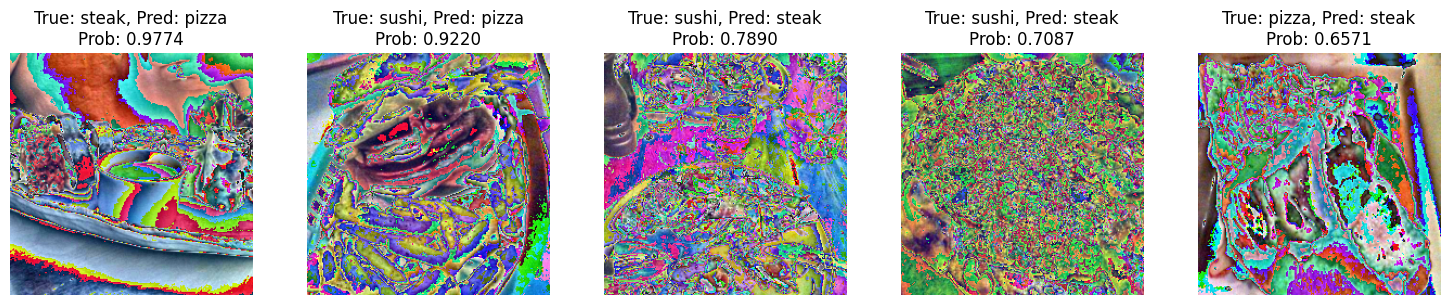

In [15]:
import pandas as pd

# Initialize lists to store sample index, true labels, predicted labels, and predicted probabilities
sample_indices = []
true_labels = []
predicted_labels = []
predicted_probs = []

# Initialize current sample index
current_index = 0

# Iterate over the test dataset and make predictions
with torch.no_grad():
    for i, (images, labels) in enumerate(test_dataloader):
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model_0(images)

        # Predicted probabilities and labels
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        # Number of samples in the current batch
        batch_size = len(images)

        # Append sample indices, true labels, predicted labels, and predicted probabilities to lists
        sample_indices.extend(range(current_index, current_index + batch_size))
        true_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(preds.cpu().numpy())
        predicted_probs.extend([probs[j, preds[j]].item() for j in range(batch_size)])  # Extract probability for predicted label

        # Update current sample index
        current_index += batch_size

# Create a DataFrame
df_predictions = pd.DataFrame({
    'sample': sample_indices,
    'label': true_labels,
    'prediction': predicted_labels,
    'pred_prob': predicted_probs
})

# Sort DataFrame by correct predictions (label == prediction)
df_correct = df_predictions[df_predictions['label'] == df_predictions['prediction']]
df_incorrect = df_predictions[df_predictions['label'] != df_predictions['prediction']]

# Sort DataFrame by predicted probabilities (descending)
df_most_wrong = df_incorrect.sort_values(by='pred_prob', ascending=False)

# Plot the top 5 "most wrong" images
import matplotlib.pyplot as plt
import torchvision.transforms.functional as TF

def plot_images(df, top_n=5):
    # Determine the number of subplots to create
    num_subplots = min(top_n, len(df))

    fig, axs = plt.subplots(1, num_subplots, figsize=(15, 3))

    # Counter for subplot index
    subplot_index = 0

    for i, row in df.head(num_subplots).iterrows():
        # Convert sample index to integer
        sample_index = int(row['sample'])

        # Retrieve image and label using the sample index
        image, label = test_dset[sample_index]

        # Convert image to PIL format
        image = TF.to_pil_image(image)

        # Convert prediction to integer
        prediction = int(row['prediction'])

        # Plot image along with true label and predicted probability
        axs[subplot_index].imshow(image)
        axs[subplot_index].set_title(f"True: {class_names[label]}, Pred: {class_names[prediction]}\nProb: {row['pred_prob']:.4f}")
        axs[subplot_index].axis('off')

        # Increment subplot index
        subplot_index += 1

    plt.tight_layout()
    plt.show()

plot_images(df_most_wrong)



## Step 4: Train the model from section 4 above with more data, say 20% of the images from Food101 of Pizza, Steak and Sushi images.
* You can find the [20% Pizza, Steak, Sushi dataset](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip) on the course GitHub. It was created with the notebook [`extras/04_custom_data_creation.ipynb`](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb).


### Get 20% data

In [16]:
!wget https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip
!mkdir -p data
!unzip pizza_steak_sushi_20_percent.zip -d data/pizza_steak_sushi_20_percent

--2024-04-28 14:15:37--  https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi_20_percent.zip [following]
--2024-04-28 14:15:37--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/data/pizza_steak_sushi_20_percent.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 31491084 (30M) [application/zip]
Saving to: ‘pizza_steak_sushi_20_percent.zip’

pizza_steak_sushi_2 100%[===================>]  30.03M   186MB/s    in 0.2s    

2

### Create DataLoaders

In [17]:
# Create a transforms pipeline
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)), # 1. Reshape all images to 224x224 (though some models may require different sizes)
    transforms.ToTensor(), # 2. Turn image values to between 0 & 1
    transforms.Normalize(mean=[0.485, 0.456, 0.406], # 3. A mean of [0.485, 0.456, 0.406] (across each colour channel)
                         std=[0.229, 0.224, 0.225]) # 4. A standard deviation of [0.229, 0.224, 0.225] (across each colour channel),
])

In [18]:
# Create training and testing DataLoader's as well as get a list of class names

data_path = "data/pizza_steak_sushi"
train_dset_20p= ImageFolder(f"{data_path}/train", transform=simple_transform)
test_dset_20p = ImageFolder(f"{data_path}/test", transform=simple_transform)
class_names = list(os.listdir(f"{data_path}/train"))  # 'pizza', 'steak', 'sushi'
print(f"Class names: {class_names}")


train_dataloader_20p = DataLoader(train_dset_20p, batch_size=32, num_workers=2, shuffle=True)
test_dataloader_20p = DataLoader(test_dset_20p, batch_size=32, num_workers=2)

train_dataloader
test_dataloader
class_names

Class names: ['sushi', 'pizza', 'steak']


['sushi', 'pizza', 'steak']

### Get a pretrained model

In [19]:
# Get a pretrained model (e.g., ResNet50)
model_pretrained = torchvision.models.resnet50(pretrained=True)

# Freeze all layers except the final fully connected layer
for param in model_pretrained.parameters():
    param.requires_grad = False
model_pretrained.fc.requires_grad = True

# Modify the final fully connected layer to match the number of classes
num_classes = len(class_names)
model_pretrained.fc = nn.Linear(model_pretrained.fc.in_features, num_classes)

# Define optimizer and loss function
optimizer = torch.optim.Adam(model_pretrained.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Move the model to the appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_pretrained.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:01<00:00, 52.6MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### Train a model with 20% of the data

In [20]:
# Train the model with 20% of the data
num_epochs = 10
for epoch in range(num_epochs):
    # Set model to train mode
    model_pretrained.train()

    # Initialize running loss
    running_loss = 0.0

    # Iterate over the training DataLoader
    for images, labels in train_dataloader_20p:
        images, labels = images.to(device), labels.to(device)

        # Zero the gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model_pretrained(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Optimize
        optimizer.step()

        # Update running loss
        running_loss += loss.item() * images.size(0)

    # Calculate average training loss for the epoch
    epoch_loss = running_loss / len(train_dataloader_20p.dataset)

    # Print epoch loss
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}")



Epoch [1/10], Loss: 1.1380
Epoch [2/10], Loss: 0.8979
Epoch [3/10], Loss: 0.6372
Epoch [4/10], Loss: 0.6376
Epoch [5/10], Loss: 0.5692
Epoch [6/10], Loss: 0.5175
Epoch [7/10], Loss: 0.5892
Epoch [8/10], Loss: 0.5977
Epoch [9/10], Loss: 0.5813
Epoch [10/10], Loss: 0.3705


## Step 5: Try a different model from [`torchvision.models`](https://pytorch.org/vision/stable/models.html) on the Pizza, Steak, Sushi data, how does this model perform?
* You'll have to change the size of the classifier layer to suit our problem.
* You may want to try an EfficientNet with a higher number than our B0, perhaps `torchvision.models.efficientnet_b2()`?
  * **Note:** Depending on the model you use you will have to prepare/transform the data in a certain way.

In [23]:
# Import necessary libraries
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, datasets
from torch.utils.data import DataLoader

# Define data transformations
# we may need to adjust the transformations based on the model requirements
# so we ensure that the image size matches the input size expected by EfficientNet-B2
transform = transforms.Compose([
    transforms.Resize((260, 260)),  # EfficientNet-B2 expects input size of 260x260
    transforms.CenterCrop(260),      # Ensure center crop to match input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the Pizza, Steak, and Sushi dataset
data_path = "data/pizza_steak_sushi"
train_dataset = datasets.ImageFolder(f"{data_path}/train", transform=transform)
test_dataset = datasets.ImageFolder(f"{data_path}/test", transform=transform)

# Create DataLoader
batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the model (EfficientNet-B2)
model = torchvision.models.efficientnet_b2(pretrained=True)

# Find the last Linear layer in the Sequential module
last_layer_index = len(model.classifier) - 1
last_linear_layer = model.classifier[last_layer_index]

# Modify the last Linear layer
num_classes = len(train_dataset.classes)
in_features = last_linear_layer.in_features
last_linear_layer = nn.Linear(in_features, num_classes)

# Replace the last Linear layer in the Sequential module
model.classifier[last_layer_index] = last_linear_layer

# Move model to appropriate device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# Train the model
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_dataset)
    print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}")

# Evaluate the model
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(f"Accuracy on test set: {accuracy:.2f}")


Epoch [1/10], Loss: 0.5957
Epoch [2/10], Loss: 0.0862
Epoch [3/10], Loss: 0.0523
Epoch [4/10], Loss: 0.1358
Epoch [5/10], Loss: 0.0916
Epoch [6/10], Loss: 0.0998
Epoch [7/10], Loss: 0.1390
Epoch [8/10], Loss: 0.0663
Epoch [9/10], Loss: 0.0550
Epoch [10/10], Loss: 0.1199
Accuracy on test set: 0.85
